In [105]:
%%capture
%pip install torch transformers
%pip install -U "huggingface_hub[cli]"
%pip install accelerate

# (recommended inside a fresh venv/conda env)
%pip uninstall -y huggingface_hub
%pip install "huggingface-hub>=0.34.0,<1.0"
# sanity check
%python -c "import transformers, huggingface_hub as h; print('transformers', transformers.__version__, 'hub', h.__version__)"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [106]:
import os
os.environ["HF_HOME"] = "./hf"
os.environ["HF_HUB_CACHE"] = "./hf/hub"
os.environ['PATH'] += ':/storage/home/hcoda1/9/kzhang430/.local/bin'
os.environ.setdefault("HF_HOME", "./hf")
os.environ.setdefault("HF_HUB_CACHE", "./hf/hub")
os.environ.setdefault("HF_DATASETS_CACHE", "./hf/datasets")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import re
import json
from huggingface_hub import login

In [107]:
!hf auth whoami

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


user:  wristycargo


# Arithmetic Experiments 2: Single-Digit Carry Sub-steps → Multi-Digit Accuracy

**Hypothesis**: Model accuracy on multi-digit addition is predicted by accuracy on the constituent single-digit sub-steps (a + b + carry_in).

**Plan**:
1. Evaluate all 200 single-digit carry sub-problems on Pythia
2. Identify 10 lowest / 10 highest scoring sub-problems
3. Construct multi-digit problems from those sub-problems
4. Test whether composite sub-step score predicts multi-digit accuracy

In [108]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
import itertools
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [109]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment Configuration — edit here
# ─────────────────────────────────────────────────────────────────────────────
import random

MODEL_NAME = "EleutherAI/pythia-2.8b-deduped"   # Pythia model to evaluate

K_SHOT     = 4    # k-shot demonstrations prepended to every prompt (0 = zero-shot)
KSHOT_SEED = 42    # random seed for demo selection (ensures reproducibility)

BATCH_SIZE_LOGPROB  = 64   # batch size for surprisal eval (lower if OOM)
BATCH_SIZE_ACCURACY = 32   # batch size for greedy-decode eval

## Utilities: Model Loading

In [123]:
PYTHIA_MODELS = [
    "EleutherAI/pythia-70m-deduped",
    "EleutherAI/pythia-160m-deduped",
    "EleutherAI/pythia-410m-deduped",
    "EleutherAI/pythia-1b-deduped",
    "EleutherAI/pythia-1.4b-deduped",
]

def load_model(name, device=device):
    print(f"Loading {name}...")
    tok = AutoTokenizer.from_pretrained(name)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id
    mdl = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    mdl.eval()
    n = sum(p.numel() for p in mdl.parameters()) / 1e6
    print(f"  Loaded: {n:.0f}M params on {next(mdl.parameters()).device}")
    return tok, mdl

## Utilities: Evaluation Functions

In [124]:
@torch.inference_mode()
def eval_logprob(model, tokenizer, df, batch_size=32, prompt_col="prompt", target_col="target"):
    """Compute per-example log-probabilities of the target given the prompt."""
    prompts = (df[prompt_col] + " ").tolist()
    targets = df[target_col].astype(str).tolist()
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    out_rows = []
    for i in tqdm(range(0, len(prompts), batch_size), desc="logprob", leave=False):
        bp = prompts[i:i+batch_size]
        bt = targets[i:i+batch_size]
        p_enc = tokenizer(bp, add_special_tokens=False)
        t_enc = tokenizer(bt, add_special_tokens=False)

        batch_ids, batch_mask, prompt_lens, target_lens = [], [], [], []
        for p_ids, t_ids in zip(p_enc["input_ids"], t_enc["input_ids"]):
            ids = p_ids + t_ids
            batch_ids.append(ids)
            batch_mask.append([1]*len(ids))
            prompt_lens.append(len(p_ids))
            target_lens.append(len(t_ids))

        max_len = max(len(x) for x in batch_ids)
        padded_ids  = [ids  + [pad_id]*(max_len-len(ids))  for ids  in batch_ids]
        padded_mask = [mask + [0]*(max_len-len(mask)) for mask in batch_mask]

        input_ids      = torch.tensor(padded_ids,  device=model.device)
        attention_mask = torch.tensor(padded_mask, device=model.device)
        logits   = model(input_ids=input_ids, attention_mask=attention_mask).logits
        log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
        next_tok  = input_ids[:, 1:]
        token_lp  = log_probs.gather(2, next_tok.unsqueeze(-1)).squeeze(-1)

        for p_len, t_len, tlp in zip(prompt_lens, target_lens, token_lp):
            start = p_len - 1
            tgt_lp = tlp[start:start+t_len]
            out_rows.append({
                "target_logprob":     tgt_lp.sum().item(),
                "avg_target_logprob": tgt_lp.mean().item(),
            })

    result = df.copy()
    result["target_logprob"]     = [r["target_logprob"]     for r in out_rows]
    result["avg_target_logprob"] = [r["avg_target_logprob"] for r in out_rows]
    result["surprisal"]          = -result["avg_target_logprob"]
    return result

In [125]:
@torch.inference_mode()
def eval_accuracy(model, tokenizer, df, batch_size=16, prompt_col="prompt",
                  target_col="target", max_new_tokens=6):
    """Greedy decoding + exact-match accuracy."""
    prompts = (df[prompt_col] + " ").tolist()
    targets = df[target_col].astype(str).tolist()

    preds = []
    for i in tqdm(range(0, len(prompts), batch_size), desc="accuracy", leave=False):
        bp  = prompts[i:i+batch_size]
        enc = tokenizer(bp, return_tensors="pt", padding=True,
                        add_special_tokens=False).to(model.device)
        out = model.generate(
            **enc, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )
        for inp_ids, out_ids in zip(enc["input_ids"], out):
            gen = tokenizer.decode(out_ids[len(inp_ids):],
                                   skip_special_tokens=True).strip()
            m = re.match(r"(-?\d+)", gen)
            preds.append(m.group(1) if m else gen)

    result = df.copy()
    result["prediction"] = preds
    result["correct"]    = [p.strip() == t.strip() for p, t in zip(preds, targets)]
    return result

In [126]:
# ─── K-shot Prompting Utilities ──────────────────────────────────────────────
#
# We use a **fixed prefix** (same k demonstrations for every query) rather than
# per-query dynamic selection.  This is the standard approach for logprob/
# surprisal evaluation because it keeps the context identical across queries,
# making surprisal values directly comparable.  The only downside is a small
# risk that the query itself appears in the demos; with k ≤ 16 and 200+
# problems this is unlikely, but `apply_kshot_prefix` optionally excludes
# the exact query row to be safe.
#
# If you prefer per-query selection (e.g. for few-shot accuracy studies),
# replace build_kshot_prefix with a function that samples differently per row.

def build_kshot_prefix(k, problem_type="single_carry", seed=KSHOT_SEED):
    """
    Build a fixed k-shot demonstration string.

    Parameters
    ----------
    k            : int  — number of demonstrations (0 returns empty string)
    problem_type : str  — "single_carry" (a+b+c=) or "2digit" (A+B=)
    seed         : int  — RNG seed for reproducibility

    Returns
    -------
    str  — newline-separated demonstration lines, e.g.
           "3 + 7 + 0 = 10\n2 + 5 + 1 = 8\n..."
    """
    if k == 0:
        return ""

    rng = random.Random(seed)

    if problem_type == "single_carry":
        pool = [(a, b, ci)
                for a, b, ci in itertools.product(range(10), range(10), [0, 1])]
        rng.shuffle(pool)
        lines = [f"{a} + {b} + {ci} = {a+b+ci}" for a, b, ci in pool[:k]]

    elif problem_type == "2digit":
        pool = [(A, B) for A in range(10, 100) for B in range(10, 100)]
        rng.shuffle(pool)
        lines = [f"{A} + {B} = {A+B}" for A, B in pool[:k]]

    else:
        raise ValueError(f"Unknown problem_type: {problem_type!r}")

    return "\n".join(lines)


def apply_kshot_prefix(df, prefix, prompt_col="prompt", out_col="eval_prompt"):
    """
    Prepend `prefix` to every prompt in df[prompt_col], storing the result in
    df[out_col].  Pass prompt_col='eval_prompt' to eval_logprob / eval_accuracy.

    If prefix is empty, eval_prompt == prompt (zero-shot pass-through).
    """
    df = df.copy()
    df[out_col] = (prefix + "\n" + df[prompt_col]) if prefix else df[prompt_col]
    return df


# Quick sanity-check
_demo = build_kshot_prefix(K_SHOT, "single_carry")
print(f"K_SHOT = {K_SHOT}")
if _demo:
    print(f"Demo prefix ({K_SHOT} examples):")
    print(_demo)
else:
    print("Zero-shot mode — no prefix added.")

K_SHOT = 4
Demo prefix (4 examples):
3 + 3 + 0 = 6
9 + 3 + 1 = 13
5 + 0 + 1 = 6
9 + 6 + 1 = 16


## Utilities: Pretraining Frequency

In [127]:
JSONL_PATH = "./pile_arith_matches_full_fresh_deduped.jsonl"

def load_freq_counts(path=JSONL_PATH):
    """
    Load addition-specific frequency counts from Pile JSONL.
    freq_ab[(a,b)] = # times 'a + b' appeared (all digit lengths).
    freq_digit[d]  = # times digit d appeared as operand in any + expression.
    """
    freq_ab    = Counter()
    freq_digit = Counter()

    with open(path, "r") as f:
        for line in f:
            r = json.loads(line.strip())
            if r.get("op") != "+":
                continue
            a, b = int(r["a"]), int(r["b"])
            freq_ab[(a, b)] += 1
            # Accumulate per-digit frequencies for single-digit operands
            if 0 <= a <= 9:
                freq_digit[a] += 1
            if 0 <= b <= 9:
                freq_digit[b] += 1

    total = sum(freq_ab.values())
    print(f"Loaded {total:,} '+' expressions from Pile")
    print(f"  Unique (a,b) pairs: {len(freq_ab):,}")
    return freq_ab, freq_digit

freq_ab, freq_digit = load_freq_counts()

Loaded 90,286 '+' expressions from Pile
  Unique (a,b) pairs: 14,062


---
# Part 1: Single-Digit Addition with Carry

We evaluate all **200 sub-problems** of the form `a + b + c_in =` where:
- `a, b ∈ {0,...,9}` are single digits
- `c_in ∈ {0, 1}` is the carry-in (the carry passed from the previous column in grade-school addition)

These 200 problems cover every possible column-level sub-step in any multi-digit addition.

We measure both **surprisal** (negative avg log-prob of the correct answer) and **exact-match accuracy** (greedy decoding).

In [128]:
# ── Generate all single-digit + carry sub-problems ──────────────────────────
def gen_single_digit_carry_problems():
    rows = []
    for a, b, carry_in in itertools.product(range(10), range(10), [0, 1]):
        result  = a + b + carry_in
        prompt  = f"{a} + {b} + {carry_in} ="
        rows.append({
            "a": a, "b": b, "carry_in": carry_in,
            "c": result,
            "prompt": prompt,
            "target": str(result),
            "has_carry_out": int(result >= 10),
            "digit_sum": a + b + carry_in,            # raw column sum
            "freq_a": freq_digit.get(a, 0),
            "freq_b": freq_digit.get(b, 0),
        })
    return pd.DataFrame(rows)

df_single = gen_single_digit_carry_problems()
print(f"Generated {len(df_single)} single-digit carry sub-problems")
print(df_single[["prompt","target","has_carry_out"]].sample(8, random_state=0))

Generated 200 single-digit carry sub-problems
          prompt target  has_carry_out
18   0 + 9 + 0 =      9              0
170  8 + 5 + 0 =     13              1
107  5 + 3 + 1 =      9              0
98   4 + 9 + 0 =     13              1
177  8 + 8 + 1 =     17              1
182  9 + 1 + 0 =     10              1
5    0 + 2 + 1 =      3              0
146  7 + 3 + 0 =     10              1


In [129]:
# ── Load model (MODEL_NAME set in Config cell above) ─────────────────────────
tokenizer, model = load_model(MODEL_NAME)

Loading EleutherAI/pythia-2.8b-deduped...
  Loaded: 2775M params on cuda:0


In [130]:
# ── Evaluate single-digit sub-problems ───────────────────────────────────────
_prefix_single = build_kshot_prefix(K_SHOT, problem_type="single_carry")
df_single_kshot = apply_kshot_prefix(df_single, _prefix_single)

df_single_eval = eval_logprob(model, tokenizer, df_single_kshot,
                               batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
df_single_eval = eval_accuracy(model, tokenizer, df_single_eval,
                                batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
df_single_eval["model"]  = MODEL_NAME
df_single_eval["k_shot"] = K_SHOT

print(f"K_SHOT={K_SHOT}  |  Overall accuracy : {df_single_eval['correct'].mean():.3f}")
print(f"K_SHOT={K_SHOT}  |  Mean surprisal   : {df_single_eval['surprisal'].mean():.3f}")
print()
print("By carry_in:")
print(df_single_eval.groupby("carry_in")[["correct","surprisal"]].mean())

logprob:   0%|          | 0/4 [00:00<?, ?it/s]

accuracy:   0%|          | 0/7 [00:00<?, ?it/s]

K_SHOT=4  |  Overall accuracy : 0.145
K_SHOT=4  |  Mean surprisal   : 13.130

By carry_in:
          correct  surprisal
carry_in                    
0            0.17  12.847266
1            0.12  13.412187


### Are there significant differences across sub-problems?

In [131]:
from scipy.stats import f_oneway, variation

surp_vals = df_single_eval["surprisal"].values
acc_vals  = df_single_eval["correct"].values.astype(float)

cv = variation(surp_vals)
print(f"Surprisal — min: {surp_vals.min():.3f}  max: {surp_vals.max():.3f}"
      f"  std: {surp_vals.std():.3f}  CV: {cv:.3f}")
print(f"Accuracy  — min: {acc_vals.min():.3f}  max: {acc_vals.max():.3f}"
      f"  std: {acc_vals.std():.3f}")
print()

# One-way ANOVA: surprisal grouped by digit_sum (proxy for intrinsic difficulty)
groups = [df_single_eval[df_single_eval["digit_sum"]==s]["surprisal"].values
          for s in sorted(df_single_eval["digit_sum"].unique())]
groups = [g for g in groups if len(g) > 1]
F, p = f_oneway(*groups)
print(f"ANOVA (surprisal ~ digit_sum): F={F:.2f}, p={p:.3e}")
print(f"  → {'Significant' if p < 0.05 else 'Not significant'} variation across digit-sum groups")

print()
print("Mean surprisal by digit_sum:")
print(df_single_eval.groupby("digit_sum")["surprisal"].mean().round(3).to_string())

Surprisal — min: 10.461  max: 15.797  std: 1.238  CV: 0.094
Accuracy  — min: 0.000  max: 1.000  std: 0.352

ANOVA (surprisal ~ digit_sum): F=42.11, p=1.610e-53
  → Significant variation across digit-sum groups

Mean surprisal by digit_sum:
digit_sum
0     10.898
1     11.854
2     12.645
3     13.001
4     12.852
5     11.613
6     11.657
7     11.818
8     12.767
9     11.692
10    14.267
11    13.644
12    14.180
13    13.793
14    14.497
15    13.970
16    14.530
17    14.920
18    14.326
19    14.344


### Heatmaps: Accuracy and Surprisal

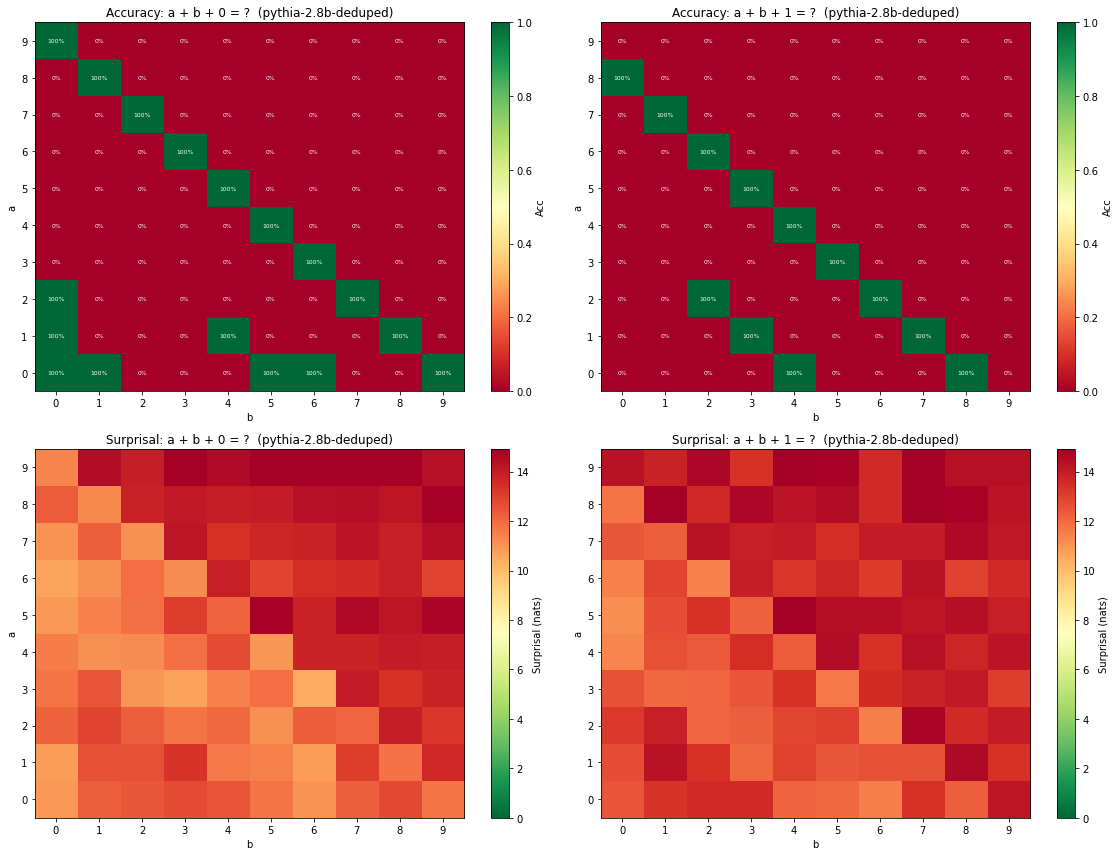

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ci, (ax_acc, ax_surp) in enumerate(zip(axes[0], axes[1])):
    sub = df_single_eval[df_single_eval["carry_in"] == ci]

    # Accuracy heatmap
    piv_acc = sub.pivot(index="a", columns="b", values="correct")
    im = ax_acc.imshow(piv_acc.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto",
                       origin="lower")
    ax_acc.set_xticks(range(10)); ax_acc.set_yticks(range(10))
    ax_acc.set_xticklabels(range(10)); ax_acc.set_yticklabels(range(10))
    ax_acc.set_xlabel("b"); ax_acc.set_ylabel("a")
    ax_acc.set_title(f"Accuracy: a + b + {ci} = ?  ({MODEL_NAME.split('/')[-1]})")
    plt.colorbar(im, ax=ax_acc, label="Acc")
    for i in range(10):
        for j in range(10):
            v = piv_acc.values[i, j]
            ax_acc.text(j, i, f"{v:.0%}", ha="center", va="center",
                        fontsize=6, color="black" if 0.2 < v < 0.85 else "white")

    # Surprisal heatmap
    piv_surp = sub.pivot(index="a", columns="b", values="surprisal")
    vmax = df_single_eval["surprisal"].quantile(0.95)
    im2  = ax_surp.imshow(piv_surp.values, cmap="RdYlGn_r",
                           vmin=0, vmax=vmax, aspect="auto", origin="lower")
    ax_surp.set_xticks(range(10)); ax_surp.set_yticks(range(10))
    ax_surp.set_xticklabels(range(10)); ax_surp.set_yticklabels(range(10))
    ax_surp.set_xlabel("b"); ax_surp.set_ylabel("a")
    ax_surp.set_title(f"Surprisal: a + b + {ci} = ?  ({MODEL_NAME.split('/')[-1]})")
    plt.colorbar(im2, ax=ax_surp, label="Surprisal (nats)")

plt.tight_layout()
plt.savefig("single_digit_carry_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### Identify 20 Lowest and 20 Highest Scoring Sub-problems

In [133]:
# Sort by accuracy (ascending), then surprisal (descending) as tiebreak
df_ranked = df_single_eval.sort_values(
    ["correct", "surprisal"], ascending=[True, False]
).reset_index(drop=True)

display_cols = ["prompt", "target", "correct", "surprisal", "avg_target_logprob",
                "prediction", "freq_a", "freq_b"]

print("═"*70)
print("20 LOWEST SCORING (hardest) sub-problems")
print("═"*70)
low_20 = df_ranked.head(20)
print(low_20[display_cols].to_string(index=False))

print()
print("═"*70)
print("20 HIGHEST SCORING (easiest) sub-problems")
print("═"*70)
high_20 = df_ranked.tail(20).sort_values("surprisal")
print(high_20[display_cols].to_string(index=False))

# Store as (a, b, carry_in) tuples and score lookups
low_triplets  = list(zip(low_20["a"],  low_20["b"],  low_20["carry_in"]))
high_triplets = list(zip(high_20["a"], high_20["b"], high_20["carry_in"]))

score_logprob  = {(r.a, r.b, r.carry_in): r.avg_target_logprob for r in df_single_eval.itertuples()}
score_surprisal = {(r.a, r.b, r.carry_in): r.surprisal          for r in df_single_eval.itertuples()}
score_correct   = {(r.a, r.b, r.carry_in): r.correct            for r in df_single_eval.itertuples()}

print(f"\nLow triplets  : {low_triplets}")
print(f"High triplets : {high_triplets}")

══════════════════════════════════════════════════════════════════════
20 LOWEST SCORING (hardest) sub-problems
══════════════════════════════════════════════════════════════════════
     prompt target  correct  surprisal  avg_target_logprob prediction  freq_a  freq_b
9 + 7 + 0 =     16    False  15.796875          -15.796875          9    3218    4303
9 + 5 + 0 =     14    False  15.703125          -15.703125          9    3218    8265
5 + 4 + 1 =     10    False  15.562500          -15.562500          9    8265   11069
9 + 8 + 0 =     17    False  15.562500          -15.562500          9    3218    4207
8 + 7 + 1 =     16    False  15.500000          -15.500000          9    4207    4303
9 + 3 + 0 =     12    False  15.281250          -15.281250          9    3218   15528
9 + 6 + 0 =     15    False  15.265625          -15.265625          9    3218    4863
9 + 7 + 1 =     17    False  15.187500          -15.187500          9    3218    4303
9 + 4 + 1 =     14    False  15.070312     

In [134]:
# ── Sanity-check: low/high sets must be disjoint ─────────────────────────────
low_set  = set(low_triplets)
high_set = set(high_triplets)
overlap  = low_set & high_set

assert not overlap, f"Overlap between low/high sets: {overlap}"
print(f"low_20  : {len(low_set)} unique triplets")
print(f"high_20 : {len(high_set)} unique triplets")
print(f"Overlap : {len(overlap)}  ✓" if not overlap else f"Overlap : {overlap}  ✗")

# Also show the score gap between the two sets
low_surp_max  = df_ranked.head(20)["surprisal"].max()
high_surp_min = df_ranked.tail(20)["surprisal"].min()
print(f"\nSurprisal range — low_20 : ≤ {low_surp_max:.3f}")
print(f"Surprisal range — high_20 : ≥ {high_surp_min:.3f}")
print(f"Gap between sets : {high_surp_min - low_surp_max:.3f}"
      f"  {'✓' if high_surp_min > low_surp_max else '✗ sets touch or overlap'}") 

low_20  : 20 unique triplets
high_20 : 20 unique triplets
Overlap : 0  ✓

Surprisal range — low_20 : ≤ 15.797
Surprisal range — high_20 : ≥ 10.461
Gap between sets : -5.336  ✗ sets touch or overlap


In [136]:
# ── Frequency comparison: are low-scoring problems also rarer in pretraining? ──
print("Frequency analysis (pretraining corpus):")
print()
print(f"  Low-20  avg freq_a : {low_20['freq_a'].mean():.1f}")
print(f"  High-20 avg freq_a : {high_20['freq_a'].mean():.1f}")
print(f"  Low-20  avg freq_b : {low_20['freq_b'].mean():.1f}")
print(f"  High-20 avg freq_b : {high_20['freq_b'].mean():.1f}")
print()

from scipy.stats import pearsonr, spearmanr
r_surp_fa, p_surp_fa = spearmanr(df_single_eval["surprisal"], df_single_eval["freq_a"])
r_surp_fb, p_surp_fb = spearmanr(df_single_eval["surprisal"], df_single_eval["freq_b"])
print(f"  Spearman corr(surprisal, freq_a): ρ={r_surp_fa:.3f}, p={p_surp_fa:.3e}")
print(f"  Spearman corr(surprisal, freq_b): ρ={r_surp_fb:.3f}, p={p_surp_fb:.3e}")

Frequency analysis (pretraining corpus):

  Low-20  avg freq_a : 5788.9
  High-20 avg freq_a : 16178.9
  Low-20  avg freq_b : 9166.9
  High-20 avg freq_b : 12726.9

  Spearman corr(surprisal, freq_a): ρ=-0.468, p=2.681e-12
  Spearman corr(surprisal, freq_b): ρ=-0.384, p=2.067e-08


---
# Part 2: Multi-Digit Evaluation Dataset

We construct **2-digit addition problems** whose column-by-column sub-steps are drawn from the selected low/high scoring single-digit problems.

For a problem `A + B` (A, B are 2-digit numbers):
- **Ones column**: `ones_A + ones_B + 0`  (carry-in is always 0 at the rightmost column)
- **Tens column**: `tens_A + tens_B + carry`,  where `carry = 1 if (ones_A + ones_B) ≥ 10 else 0`

We form **four categories**:
| Category | Ones sub-step | Tens sub-step |
|----------|--------------|---------------|
| low-low  | low-scoring  | low-scoring   |
| high-high| high-scoring | high-scoring  |
| low-high | low-scoring  | high-scoring  |
| high-low | high-scoring | low-scoring   |

We also evaluate **all 90×90 = 8100** two-digit problems for a broader regression analysis.

In [137]:
def construct_controlled_2digit(low_triplets, high_triplets, score_surprisal, score_logprob):
    """
    Construct 2-digit addition problems whose sub-steps come from the low/high sets.
    Returns a deduplicated DataFrame with composite scores pre-attached.
    """
    # Index by carry_in for fast lookup
    low_by_ci  = defaultdict(list)
    high_by_ci = defaultdict(list)
    for a, b, ci in low_triplets:
        low_by_ci[ci].append((a, b))
    for a, b, ci in high_triplets:
        high_by_ci[ci].append((a, b))
    pool = {"low": low_by_ci, "high": high_by_ci}

    problems = []
    categories = [
        ("low-low",   low_triplets,  "low"),
        ("high-high", high_triplets, "high"),
        ("low-high",  low_triplets,  "high"),
        ("high-low",  high_triplets, "low"),
    ]

    seen = set()
    for cat, ones_pool, tens_label in categories:
        # Ones column always has carry_in=0
        ones_cands = [(a, b) for a, b, ci in ones_pool if ci == 0]
        for ones_a, ones_b in ones_cands:
            carry_to_tens = 1 if (ones_a + ones_b) >= 10 else 0
            tens_cands = pool[tens_label].get(carry_to_tens, [])
            for tens_a, tens_b in tens_cands:
                A = tens_a * 10 + ones_a
                B = tens_b * 10 + ones_b
                key = (A, B)
                if key in seen:
                    continue
                seen.add(key)
                C = A + B
                s_ones = score_surprisal.get((ones_a, ones_b, 0), float("nan"))
                s_tens = score_surprisal.get((tens_a, tens_b, carry_to_tens), float("nan"))
                lp_ones = score_logprob.get((ones_a, ones_b, 0), float("nan"))
                lp_tens = score_logprob.get((tens_a, tens_b, carry_to_tens), float("nan"))
                problems.append({
                    "category": cat,
                    "A": A, "B": B, "C": C,
                    "prompt": f"{A} + {B} =",
                    "target": str(C),
                    "ones_a": ones_a, "ones_b": ones_b,
                    "tens_a": tens_a, "tens_b": tens_b,
                    "carry_to_tens": carry_to_tens,
                    "n_result_digits": len(str(C)),
                    "surp_ones": s_ones,
                    "surp_tens": s_tens,
                    "lp_ones":   lp_ones,
                    "lp_tens":   lp_tens,
                    # Composite scores
                    "comp_surp_max":  max(s_ones, s_tens),       # bottleneck (hardest step)
                    "comp_surp_mean": (s_ones + s_tens) / 2,
                    "comp_lp_sum":    lp_ones + lp_tens,         # log(p_ones * p_tens)
                    "comp_lp_min":    min(lp_ones, lp_tens),     # weakest step
                })

    return pd.DataFrame(problems)

df_ctrl = construct_controlled_2digit(low_triplets, high_triplets, score_surprisal, score_logprob)
print(f"Controlled dataset: {len(df_ctrl)} unique 2-digit problems")
print(df_ctrl["category"].value_counts())

Controlled dataset: 475 unique 2-digit problems
high-high    196
high-low     126
low-low       99
low-high      54
Name: category, dtype: int64


In [138]:
# ── All 2-digit addition problems with composite scores ──────────────────────
def gen_all_2digit_problems(score_surprisal, score_logprob):
    rows = []
    for A in range(10, 100):
        for B in range(10, 100):
            C = A + B
            ones_a, ones_b = A % 10, B % 10
            tens_a, tens_b = A // 10, B // 10
            carry_to_tens  = 1 if (ones_a + ones_b) >= 10 else 0

            s_ones  = score_surprisal.get((ones_a, ones_b, 0), float("nan"))
            s_tens  = score_surprisal.get((tens_a, tens_b, carry_to_tens), float("nan"))
            lp_ones = score_logprob.get((ones_a, ones_b, 0), float("nan"))
            lp_tens = score_logprob.get((tens_a, tens_b, carry_to_tens), float("nan"))

            rows.append({
                "A": A, "B": B, "C": C,
                "prompt": f"{A} + {B} =",
                "target": str(C),
                "ones_a": ones_a, "ones_b": ones_b,
                "tens_a": tens_a, "tens_b": tens_b,
                "carry_to_tens": carry_to_tens,
                "n_result_digits": len(str(C)),
                "surp_ones": s_ones,
                "surp_tens": s_tens,
                "comp_surp_max":  max(s_ones, s_tens),
                "comp_surp_mean": (s_ones + s_tens) / 2,
                "comp_lp_sum":    lp_ones + lp_tens,
                "comp_lp_min":    min(lp_ones, lp_tens),
            })
    return pd.DataFrame(rows)

df_all2 = gen_all_2digit_problems(score_surprisal, score_logprob)
print(f"Full 2-digit dataset: {len(df_all2)} problems")

# Stratified sample for evaluation (manageable runtime)
df_all2["score_quartile"] = pd.qcut(df_all2["comp_surp_mean"], 4,
                                     labels=["Q1_easy","Q2","Q3","Q4_hard"])
df_all2_sample = (
    df_all2.groupby("score_quartile", group_keys=False)
           .apply(lambda x: x.sample(min(150, len(x)), random_state=42))
           .reset_index(drop=True)
)
print(f"Stratified sample: {len(df_all2_sample)}")
print(df_all2_sample["score_quartile"].value_counts().sort_index())

Full 2-digit dataset: 8100 problems
Stratified sample: 600
Q1_easy    150
Q2         150
Q3         150
Q4_hard    150
Name: score_quartile, dtype: int64


### Evaluate Multi-Digit Problems

In [139]:
# ── Evaluate controlled (low/high) dataset ───────────────────────────────────
_prefix_2d = build_kshot_prefix(K_SHOT, problem_type="2digit")
df_ctrl_kshot = apply_kshot_prefix(df_ctrl, _prefix_2d)

print("Evaluating controlled 2-digit problems...")
df_ctrl_eval = eval_logprob(model, tokenizer, df_ctrl_kshot,
                             batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
df_ctrl_eval = eval_accuracy(model, tokenizer, df_ctrl_eval,
                              batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
df_ctrl_eval["model"]  = MODEL_NAME
df_ctrl_eval["k_shot"] = K_SHOT

print("\nAccuracy by category:")
print(df_ctrl_eval.groupby("category")[["correct","surprisal"]].mean().round(3))

Evaluating controlled 2-digit problems...


logprob:   0%|          | 0/8 [00:00<?, ?it/s]

accuracy:   0%|          | 0/15 [00:00<?, ?it/s]


Accuracy by category:
           correct  surprisal
category                     
high-high    0.066      9.788
high-low     0.008      7.556
low-high     0.037      8.792
low-low      0.051      7.675


In [140]:
# ── Evaluate stratified 2-digit sample ───────────────────────────────────────
_prefix_2d = build_kshot_prefix(K_SHOT, problem_type="2digit")
df_s2_kshot = apply_kshot_prefix(df_all2, _prefix_2d) # or use df_all2_sample for smaller eval set

print("Evaluating stratified 2-digit sample...")
df_s2_eval = eval_logprob(model, tokenizer, df_s2_kshot,
                           batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
df_s2_eval = eval_accuracy(model, tokenizer, df_s2_eval,
                            batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
df_s2_eval["model"]  = MODEL_NAME
df_s2_eval["k_shot"] = K_SHOT

print(f"\nK_SHOT={K_SHOT}  |  Overall 2-digit accuracy: {df_s2_eval['correct'].mean():.3f}")
print("\nAccuracy by composite-score quartile:")
print(df_s2_eval.groupby("score_quartile")[["correct","surprisal"]].mean().round(3))

Evaluating stratified 2-digit sample...


logprob:   0%|          | 0/127 [00:00<?, ?it/s]

accuracy:   0%|          | 0/254 [00:00<?, ?it/s]


K_SHOT=4  |  Overall 2-digit accuracy: 0.047

Accuracy by composite-score quartile:
                correct  surprisal
score_quartile                    
Q1_easy           0.067      8.022
Q2                0.053      7.828
Q3                0.032      7.639
Q4_hard           0.035      7.537


---
# Part 3: Composite Score Analysis

We test whether the composite single-digit sub-step score **predicts** multi-digit accuracy, after controlling for:
- `n_result_digits`: whether result has 2 or 3 digits
- `log_freq_A`, `log_freq_B`: log pretraining frequency of the operands

In [151]:
from scipy.stats import pearsonr, spearmanr, ttest_ind

composite_cols = ["comp_surp_max", "comp_surp_mean", "comp_lp_sum", "comp_lp_min"]

print("=== Correlation: composite sub-step score → multi-digit surprisal ===\n")
for col in composite_cols:
    x = df_s2_eval[col].values
    y = df_s2_eval["surprisal"].values
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)
    print(f"  {col:22s}  Pearson r={r_p:+.3f} (p={p_p:.2e})  "
          f"Spearman ρ={r_s:+.3f} (p={p_s:.2e})")

print()
print("=== Correlation: composite sub-step score → multi-digit accuracy ===\n")
for col in composite_cols:
    x = df_s2_eval[col].values
    y = df_s2_eval["correct"].values.astype(float)
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)
    print(f"  {col:22s}  Pearson r={r_p:+.3f} (p={p_p:.2e})  "
          f"Spearman ρ={r_s:+.3f} (p={p_s:.2e})")

=== Correlation: composite sub-step score → multi-digit surprisal ===

  comp_surp_max           Pearson r=-0.098 (p=6.78e-19)  Spearman ρ=-0.100 (p=2.77e-19)
  comp_surp_mean          Pearson r=-0.104 (p=4.86e-21)  Spearman ρ=-0.112 (p=6.17e-24)
  comp_lp_sum             Pearson r=+0.104 (p=4.86e-21)  Spearman ρ=+0.112 (p=6.17e-24)
  comp_lp_min             Pearson r=+0.098 (p=6.78e-19)  Spearman ρ=+0.100 (p=2.77e-19)

=== Correlation: composite sub-step score → multi-digit accuracy ===

  comp_surp_max           Pearson r=-0.083 (p=6.04e-14)  Spearman ρ=-0.087 (p=3.31e-15)
  comp_surp_mean          Pearson r=-0.057 (p=3.31e-07)  Spearman ρ=-0.062 (p=2.84e-08)
  comp_lp_sum             Pearson r=+0.057 (p=3.31e-07)  Spearman ρ=+0.062 (p=2.84e-08)
  comp_lp_min             Pearson r=+0.083 (p=6.04e-14)  Spearman ρ=+0.087 (p=3.31e-15)


In [152]:
# ── Attach frequency features for regression controls ────────────────────────
# Pile frequency of each operand value (summing over positions)
operand_freq = Counter()
for (a, b), cnt in freq_ab.items():
    operand_freq[a] += cnt
    operand_freq[b] += cnt

for df_ in [df_s2_eval, df_ctrl_eval]:
    df_["log_freq_A"] = df_["A"].map(lambda x: np.log1p(operand_freq.get(x, 0)))
    df_["log_freq_B"] = df_["B"].map(lambda x: np.log1p(operand_freq.get(x, 0)))
    df_["log_freq_AB"] = df_[["A","B"]].apply(
        lambda r: np.log1p(freq_ab.get((r.A, r.B), 0)), axis=1)

print("Frequency features attached.")
print(df_s2_eval[["A","B","log_freq_A","log_freq_B","log_freq_AB"]].describe().round(2))

Frequency features attached.
             A        B  log_freq_A  log_freq_B  log_freq_AB
count  8100.00  8100.00     8100.00     8100.00      8100.00
mean     54.50    54.50        5.31        5.31         0.36
std      25.98    25.98        1.01        1.01         0.65
min      10.00    10.00        3.85        3.85         0.00
25%      32.00    32.00        4.41        4.41         0.00
50%      54.50    54.50        5.10        5.10         0.00
75%      77.00    77.00        6.06        6.06         0.69
max      99.00    99.00        8.06        8.06         5.43


In [150]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Logistic regression: predicting accuracy (binary) ────────────────────────
y_acc  = df_s2_eval["correct"].values.astype(int)

feature_sets = {
    "composite only":            ["comp_surp_mean"],
    "+ digits":                  ["comp_surp_mean", "n_result_digits"],
    "+ frequency":               ["comp_surp_mean", "n_result_digits",
                                   "log_freq_A", "log_freq_B"],
    "+ freq_AB (joint)":         ["comp_surp_mean", "n_result_digits",
                                   "log_freq_AB"],
    "no composite (controls)":   ["n_result_digits",
                                   "log_freq_A", "log_freq_B"],
}

print("=== Logistic Regression → accuracy  (AUC-ROC) ===\n")
for name, feats in feature_sets.items():
    X   = df_s2_eval[feats].values
    Xsc = StandardScaler().fit_transform(X)
    try:
        lr  = LogisticRegression(max_iter=500, random_state=42)
        lr.fit(Xsc, y_acc)
        auc = roc_auc_score(y_acc, lr.predict_proba(Xsc)[:, 1])
        print(f"  {name:45s}: AUC = {auc:.3f}")
    except Exception as e:
        print(f"  {name:45s}: failed ({e})")

# ── Linear regression: predicting surprisal (continuous) ─────────────────────
y_surp = df_s2_eval["surprisal"].values

print("\n=== Linear Regression → surprisal  (R²) ===\n")
for name, feats in feature_sets.items():
    X   = df_s2_eval[feats].values
    Xsc = StandardScaler().fit_transform(X)
    lr  = LinearRegression()
    lr.fit(Xsc, y_surp)
    r2  = lr.score(Xsc, y_surp)
    print(f"  {name:45s}: R² = {r2:.3f}")

=== Logistic Regression → accuracy  (AUC-ROC) ===

  composite only                               : AUC = 0.584
  + digits                                     : AUC = 0.771
  + frequency                                  : AUC = 0.781
  + freq_AB (joint)                            : AUC = 0.771
  no composite (controls)                      : AUC = 0.761

=== Linear Regression → surprisal  (R²) ===

  composite only                               : R² = 0.011
  + digits                                     : R² = 0.035
  + frequency                                  : R² = 0.081
  + freq_AB (joint)                            : R² = 0.047
  no composite (controls)                      : R² = 0.081


### Controlled Experiment: Category-Level Analysis

In [144]:
print("=== Controlled 2-digit experiment (low/high sub-problem categories) ===\n")

cat_order = ["low-low", "low-high", "high-low", "high-high"]
present   = [c for c in cat_order if c in df_ctrl_eval["category"].values]

summary = df_ctrl_eval.groupby("category").agg(
    n             =("correct", "count"),
    accuracy      =("correct", "mean"),
    mean_surprisal=("surprisal", "mean"),
    mean_comp_surp=("comp_surp_mean", "mean"),
).reindex(present)
print(summary.round(3).to_string())

print("\n=== Pairwise t-tests on surprisal ===")
from scipy.stats import ttest_ind
for c1, c2 in itertools.combinations(present, 2):
    s1 = df_ctrl_eval[df_ctrl_eval.category == c1]["surprisal"]
    s2 = df_ctrl_eval[df_ctrl_eval.category == c2]["surprisal"]
    t, p = ttest_ind(s1, s2, equal_var=False)
    sig = "**" if p < 0.01 else ("*" if p < 0.05 else "")
    print(f"  {c1} vs {c2}: t={t:.2f}, p={p:.3e} {sig}")

=== Controlled 2-digit experiment (low/high sub-problem categories) ===

             n  accuracy  mean_surprisal  mean_comp_surp
category                                                
low-low     99     0.051           7.675          15.060
low-high    54     0.037           8.792          13.459
high-low   126     0.008           7.556          13.238
high-high  196     0.066           9.788          11.299

=== Pairwise t-tests on surprisal ===
  low-low vs low-high: t=-4.53, p=1.278e-05 **
  low-low vs high-low: t=0.54, p=5.925e-01 
  low-low vs high-high: t=-10.16, p=1.100e-19 **
  low-high vs high-low: t=5.43, p=2.881e-07 **
  low-high vs high-high: t=-4.67, p=9.063e-06 **
  high-low vs high-high: t=-12.05, p=3.892e-27 **


### Visualizations

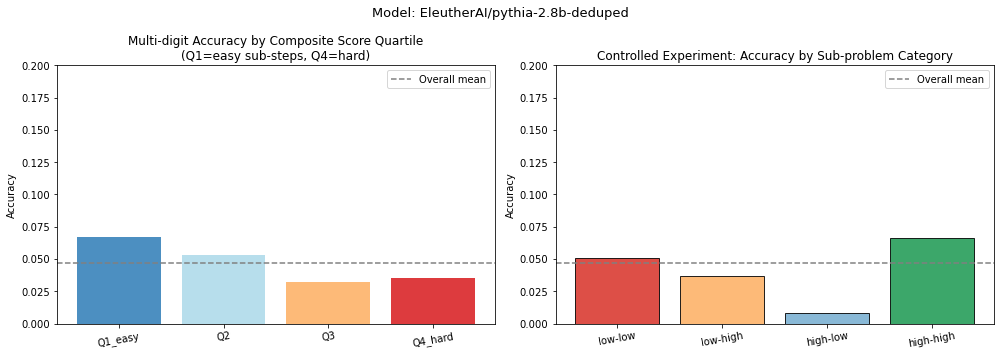

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. Accuracy by composite quartile ────────────────────────────────────────
ax = axes[0]
q_acc = df_s2_eval.groupby("score_quartile")["correct"].mean()
ax.bar(range(len(q_acc)), q_acc.values,
       color=["#2c7bb6","#abd9e9","#fdae61","#d7191c"], alpha=0.85)
ax.set_xticks(range(len(q_acc)))
ax.set_xticklabels(q_acc.index, rotation=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 0.2)
ax.set_title("Multi-digit Accuracy by Composite Score Quartile\n(Q1=easy sub-steps, Q4=hard)")
ax.axhline(df_s2_eval["correct"].mean(), color="gray", ls="--", label="Overall mean")
ax.legend()

# ── 2. Controlled experiment: category accuracy ───────────────────────────────
ax = axes[1]
if len(df_ctrl_eval) > 0:
    cat_acc = df_ctrl_eval.groupby("category")["correct"].mean().reindex(present)
    colors  = {"low-low": "#d73027", "low-high": "#fdae61",
               "high-low": "#74add1", "high-high": "#1a9850"}
    ax.bar(range(len(cat_acc)),
           cat_acc.values,
           color=[colors.get(c, "gray") for c in cat_acc.index],
           alpha=0.85, edgecolor="black")
    ax.set_xticks(range(len(cat_acc)))
    ax.set_xticklabels(cat_acc.index, rotation=10)
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 0.2)
    ax.set_title("Controlled Experiment: Accuracy by Sub-problem Category")
    ax.axhline(df_s2_eval["correct"].mean(), color="gray", ls="--", label="Overall mean")
    ax.legend()

plt.suptitle(f"Model: {MODEL_NAME}", fontsize=13)
plt.tight_layout()
plt.savefig("composite_score_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Confound Analysis: Frequency vs Composite Score

In [102]:
# Is the predictive power of composite score just because high-frequency
# sub-problems also appear in high-frequency multi-digit problems?

from scipy.stats import partial_corr_available  # check; use pingouin if available
try:
    import pingouin as pg
    df_tmp = df_s2_eval[["surprisal", "comp_surp_mean",
                          "log_freq_AB"]].dropna()
    pc = pg.partial_corr(data=df_tmp, x="comp_surp_mean", y="surprisal",
                          covar=["log_freq_AB"])
    print("Partial correlation (comp_surp_mean → surprisal | carry, freq_AB):")
    print(pc.round(3))
except (ImportError, AttributeError):
    # Fallback: residualise manually
    from sklearn.linear_model import LinearRegression
    import numpy as np

    def partial_r(df, x_col, y_col, covar_cols):
        """Compute partial correlation of x and y after removing covariate variance."""
        df_ = df[[x_col, y_col] + covar_cols].dropna()
        X_c = df_[covar_cols].values
        # Residualise x on covariates
        lrx = LinearRegression().fit(X_c, df_[x_col].values)
        res_x = df_[x_col].values - lrx.predict(X_c)
        # Residualise y on covariates
        lry = LinearRegression().fit(X_c, df_[y_col].values)
        res_y = df_[y_col].values - lry.predict(X_c)
        r, p = pearsonr(res_x, res_y)
        return r, p

    covars = ["n_result_digits", "log_freq_A", "log_freq_B"]
    print("Partial correlations (controlling for carry, digits, operand frequencies):\n")
    for col in composite_cols:
        r, p = partial_r(df_s2_eval, col, "surprisal", covars)
        print(f"  {col:22s} → surprisal  : partial r = {r:+.3f}, p = {p:.2e}")
    print()
    for col in composite_cols:
        r, p = partial_r(df_s2_eval, col, "correct", covars)
        print(f"  {col:22s} → accuracy   : partial r = {r:+.3f}, p = {p:.2e}")

ImportError: cannot import name 'partial_corr_available' from 'scipy.stats' (/storage/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/scipy/stats/__init__.py)

### Extend to Multiple Model Sizes

In [ ]:
# # ── Multi-model evaluation ────────────────────────────────────────────────────
# # Uncomment and adjust MODEL_NAMES list for multi-model runs.
# # Due to memory constraints, load one model at a time.

# all_results = {}  # model_name -> {"single": df_s, "multi": df_m}

# for model_name in PYTHIA_MODELS[:3]:   # start with small models
#     tok_i, mdl_i = load_model(model_name)

#     df_s_i = eval_logprob(mdl_i, tok_i, df_single, batch_size=64)
#     df_s_i = eval_accuracy(mdl_i, tok_i, df_s_i,  batch_size=32)
#     df_s_i["model"] = model_name

#     # Recompute score lookups for this model
#     sc_lp_i = {(r.a, r.b, r.carry_in): r.avg_target_logprob for r in df_s_i.itertuples()}
#     sc_su_i = {(r.a, r.b, r.carry_in): r.surprisal           for r in df_s_i.itertuples()}
#     df_s2_i = gen_all_2digit_problems(sc_su_i, sc_lp_i)
#     df_s2_samp_i = df_s2_i.sample(500, random_state=42)
#     df_s2_samp_i = eval_logprob(mdl_i, tok_i, df_s2_samp_i, batch_size=32)
#     df_s2_samp_i = eval_accuracy(mdl_i, tok_i, df_s2_samp_i, batch_size=16)
#     df_s2_samp_i["model"] = model_name

#     all_results[model_name] = {"single": df_s_i, "multi": df_s2_samp_i}

#     # Free memory
#     del mdl_i, tok_i
#     torch.cuda.empty_cache()

# print("Multi-model evaluation complete")

print("(Multi-model block is commented out. Uncomment to run across model sizes.)")

(Multi-model block is commented out. Uncomment to run across model sizes.)
